# Кластеризация для датасета Cirrhosis
*Цель:* выделить естественные группы пациентов и сравнить их с клинической меткой Status


# Метрики кластеризации

В ноутбуке используются следующие метрики:

- **Silhouette score** — показывает, насколько компактны и разделимы кластеры;
- **Adjusted Rand Index (ARI)** — показывает, насколько разбиение совпадает с внешней меткой Status;
- **Inertia** — внутренняя сумма квадратов расстояний для KMeans;
- **Количество шумовых точек** — важно для DBSCAN, так как этот алгоритм может помечать часть объектов как шум.


In [1]:
import os
import warnings

os.environ["OMP_NUM_THREADS"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="husl")
%matplotlib inline


# Загрузка и первичный анализ данных


In [2]:
DATA_PATH = "D:/ProjectAI/ai_brief-main/cirrhosis_preprocessed.csv"
df = pd.read_csv(DATA_PATH)
df.head()


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_years
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,...,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,58.805479
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,...,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,56.484932
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,...,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,70.120548
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,...,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,54.778082
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,...,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,38.131507


In [3]:
summary_df = pd.DataFrame(
    {
        "Показатель": [
            "Число строк",
            "Число столбцов",
            "Число пропусков",
            "Число дубликатов",
            "Число уникальных значений Status",
            "Число уникальных значений Stage",
        ],
        "Значение": [
            df.shape[0],
            df.shape[1],
            int(df.isna().sum().sum()),
            int(df.duplicated().sum()),
            df["Status"].nunique(),
            df["Stage"].nunique(),
        ],
    }
)

status_stage_df = pd.DataFrame(
    {
        "Status_count": df["Status"].value_counts().sort_index(),
        "Stage_count": df["Stage"].value_counts().sort_index(),
    }
).fillna(0).astype(int)

display(summary_df)
display(status_stage_df)


,Показатель,Значение
0,Число строк,312
1,Число столбцов,21
2,Число пропусков,0
3,Число дубликатов,0
4,Число уникальных значений Status,3
5,Число уникальных значений Stage,4


,Status_count,Stage_count
0.0,168,0
1.0,19,16
2.0,125,67
3.0,0,120
4.0,0,109


,Корреляция с Status
Bilirubin,0.437
N_Days,-0.424
Prothrombin,0.406
ID,-0.397
Copper,0.387
Stage,0.345
Hepatomegaly,0.335
Edema,0.320
Ascites,0.317
Albumin,-0.310


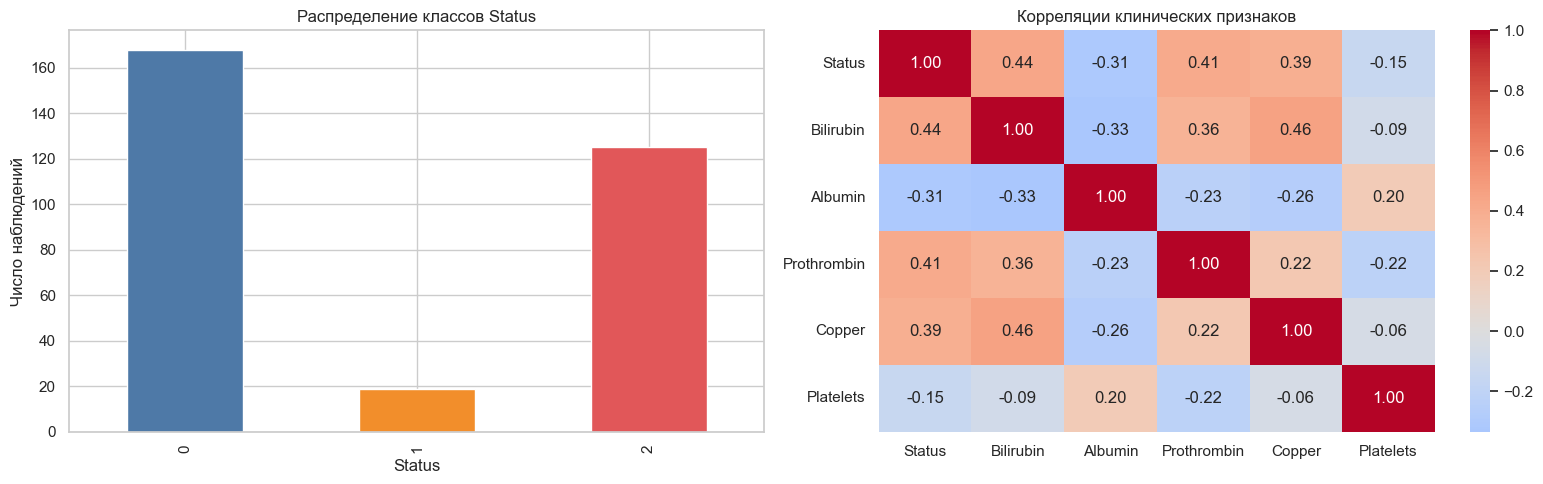

In [4]:
status_corr = (
    df.corr(numeric_only=True)["Status"]
    .drop("Status")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(status_corr.head(10).round(3).to_frame("Корреляция с Status"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df["Status"].round().astype(int).value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    color=["#4E79A7", "#F28E2B", "#E15759"],
)
axes[0].set_title("Распределение классов Status")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Число наблюдений")

heatmap_cols = ["Status", "Bilirubin", "Albumin", "Prothrombin", "Copper", "Platelets"]
sns.heatmap(
    df[heatmap_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
)
axes[1].set_title("Корреляции клинических признаков")

plt.tight_layout()
plt.show()


# Подготовка данных к кластеризации


Для кластеризации используем только признаки пациента и исключаем:

ID, потому что это технический идентификатор;
Status, потому что это внешняя метка для оценки кластеров;
Stage и N_Days, потому что это уже очень близкие к исходу переменные;
Age, потому что в датасете уже есть более интерпретируемый признак Age_years

Перед кластеризацией признаки масштабируются, так как их диапазоны сильно различаются


In [5]:
target_col = "Status"
drop_from_features = {"ID", "Status", "Stage", "N_Days", "Age"}
feature_cols = [col for col in df.columns if col not in drop_from_features]

X = df[feature_cols].copy()
y = df[target_col].round().astype(int)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

plot_cols = ["Bilirubin", "Albumin", "Prothrombin"]

print("Число признаков для кластеризации:", X.shape[1])
print("Используемые признаки:", feature_cols)
X_scaled.head()


Число признаков для кластеризации: 16
Используемые признаки: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Age_years']


,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Age_years
0,-0.987261,-0.361158,3.464102,0.974679,1.570563,3.245281,2.485914,-0.465435,-2.194559,0.686539,-0.123847,0.271931,0.788477,-0.757812,1.470371,0.827904
1,-0.987261,-0.361158,-0.288675,0.974679,1.570563,-0.403467,-0.476689,-0.280389,1.478942,-0.510307,2.532642,-0.159629,-0.565855,-0.430950,-0.125301,0.608395
2,-0.987261,2.768875,-0.288675,-1.025978,-0.636715,1.420907,-0.410362,-0.849066,-0.095416,1.320163,-0.686329,-0.467356,-1.097915,-1.169026,1.270912,1.898239
3,-0.987261,-0.361158,-0.288675,0.974679,1.570563,1.420907,-0.321927,-0.542161,-2.337683,-0.392969,1.936935,-1.093939,-0.501363,-0.831620,-0.424490,0.446938
4,1.012904,-0.361158,-0.288675,0.974679,1.570563,-0.403467,0.031817,-0.384195,0.023854,0.534000,-0.613796,-0.166165,-0.823823,-1.327185,0.173887,-1.127724


# KMeans


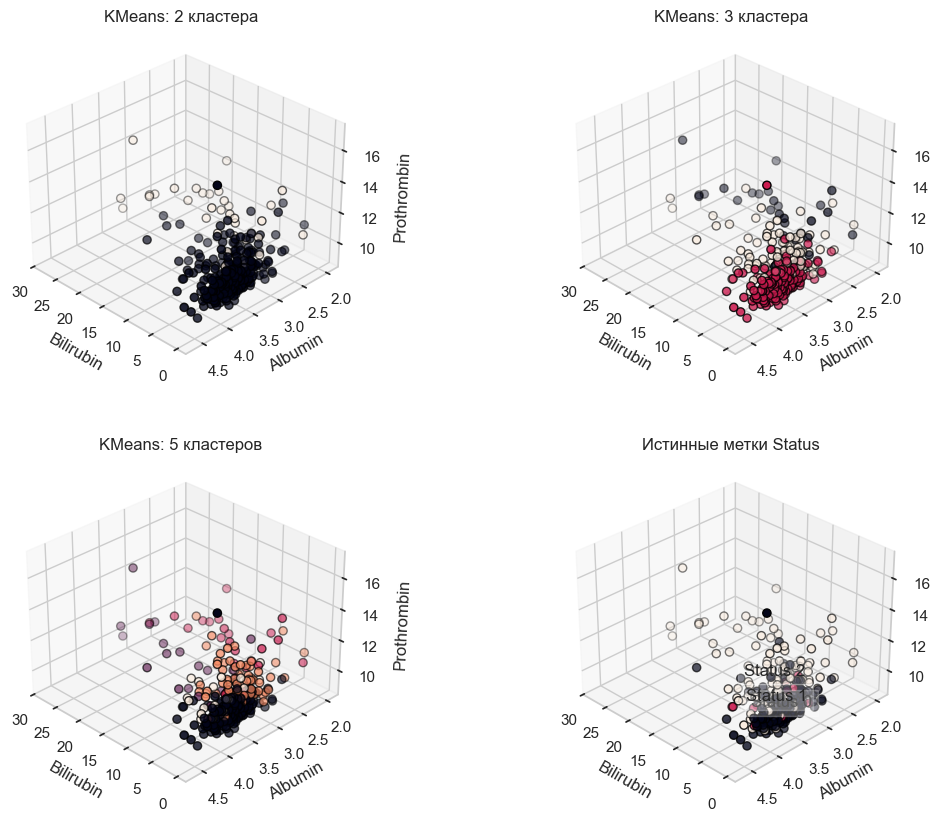

In [6]:
status_values = sorted(y.unique())
status_names = {value: f"Status {value}" for value in status_values}

estimators = [
    ("kmeans_2", KMeans(n_clusters=2, random_state=42, n_init=20)),
    ("kmeans_3", KMeans(n_clusters=3, random_state=42, n_init=20)),
    ("kmeans_5", KMeans(n_clusters=5, random_state=42, n_init=20)),
]

fig = plt.figure(figsize=(13, 10))
titles = ["KMeans: 2 кластера", "KMeans: 3 кластера", "KMeans: 5 кластеров"]

for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=30, azim=135)
    est.fit(X_scaled)
    labels = est.labels_
    ax.scatter(
        X[plot_cols[0]],
        X[plot_cols[1]],
        X[plot_cols[2]],
        c=labels.astype(float),
        edgecolor="k",
        s=35,
    )
    ax.set_xlabel(plot_cols[0])
    ax.set_ylabel(plot_cols[1])
    ax.set_zlabel(plot_cols[2])
    ax.set_title(title)

ax = fig.add_subplot(2, 2, 4, projection="3d", elev=30, azim=135)
for status_value in status_values:
    ds = df[y == status_value]
    ax.text3D(
        ds[plot_cols[0]].mean(),
        ds[plot_cols[1]].mean(),
        ds[plot_cols[2]].mean(),
        status_names[status_value],
        horizontalalignment="center",
        bbox=dict(alpha=0.25, edgecolor="w", facecolor="w"),
    )

ax.scatter(
    X[plot_cols[0]],
    X[plot_cols[1]],
    X[plot_cols[2]],
    c=y,
    edgecolor="k",
    s=35,
)
ax.set_xlabel(plot_cols[0])
ax.set_ylabel(plot_cols[1])
ax.set_zlabel(plot_cols[2])
ax.set_title("Истинные метки Status")

plt.subplots_adjust(wspace=0.2, hspace=0.25)
plt.show()


На трехмерной проекции видно, что в данных есть выраженный слой более тяжелых наблюдений.
При k = 2 модель хорошо отделяет этот слой от остальной массы пациентов, а при большем числе кластеров
разбиение становится детальнее и начинает выделять подгруппы внутри каждого состояния.


In [7]:
n_clusters = np.arange(2, 11)

silhouette_score_values = []
adjusted_rand_score_values = []
inertia_values = []
rows = []

for n in n_clusters:
    clusterer = KMeans(n_clusters=n, random_state=42, n_init=20)
    labels = clusterer.fit_predict(X_scaled)

    silhouette = metrics.silhouette_score(X_scaled, labels)
    ari = adjusted_rand_score(y, labels)
    inertia = clusterer.inertia_

    silhouette_score_values.append(silhouette)
    adjusted_rand_score_values.append(ari)
    inertia_values.append(inertia)
    rows.append(
        {
            "n_clusters": n,
            "silhouette": silhouette,
            "ari": ari,
            "inertia": inertia,
        }
    )

metrics_df = pd.DataFrame(rows)
best_by_silhouette = metrics_df.loc[metrics_df["silhouette"].idxmax()]
best_by_ari = metrics_df.loc[metrics_df["ari"].idxmax()]

display(metrics_df.round(4))


,n_clusters,silhouette,ari,inertia
0,2,0.3399,0.0754,4252.3042
1,3,0.1473,0.2440,3868.1206
2,4,0.1609,0.2248,3568.2596
3,5,0.1516,0.2452,3297.4333
4,6,0.1405,0.1715,3110.2627
5,7,0.1210,0.1177,2939.2216
6,8,0.1237,0.1234,2809.8067
7,9,0.1020,0.0812,2729.2436
8,10,0.1187,0.0839,2605.8532


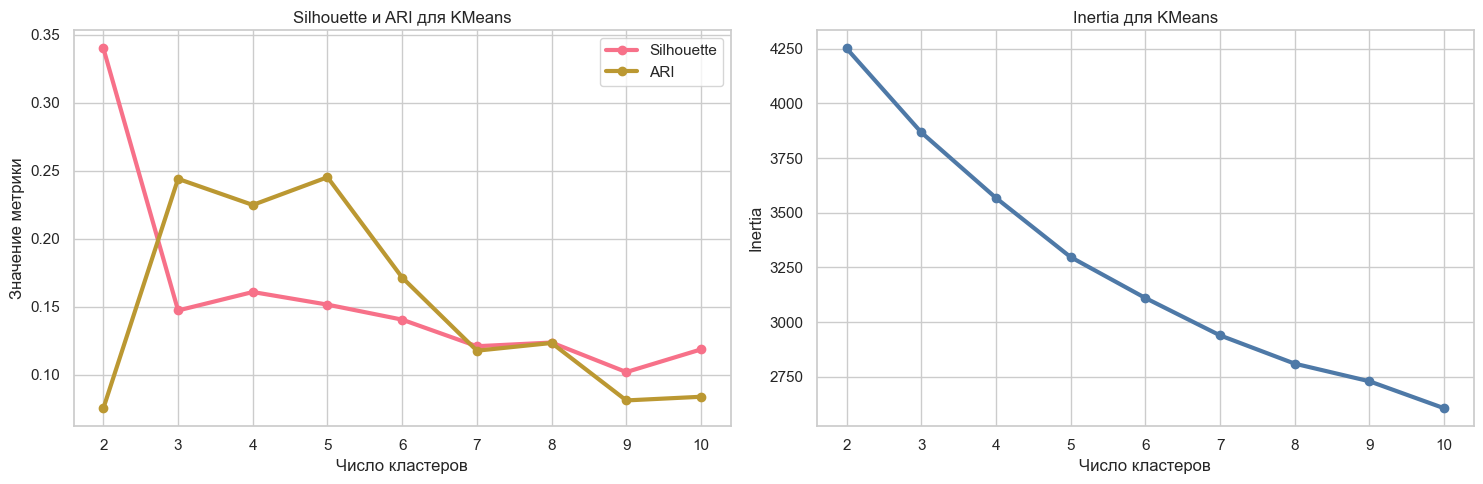

Лучшее число кластеров по silhouette: 2
Лучшее значение silhouette: 0.3399
Лучшее число кластеров по ARI: 5
Лучшее значение ARI: 0.2452
Вывод: самые компактные кластеры и кластеры, лучше всего согласованные с Status, не совпадают по числу групп.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(n_clusters, silhouette_score_values, marker="o", linewidth=3, label="Silhouette")
axes[0].plot(n_clusters, adjusted_rand_score_values, marker="o", linewidth=3, label="ARI")
axes[0].set_title("Silhouette и ARI для KMeans")
axes[0].set_xlabel("Число кластеров")
axes[0].set_ylabel("Значение метрики")
axes[0].legend()

axes[1].plot(n_clusters, inertia_values, marker="o", linewidth=3, color="#4E79A7")
axes[1].set_title("Inertia для KMeans")
axes[1].set_xlabel("Число кластеров")
axes[1].set_ylabel("Inertia")

plt.tight_layout()
plt.show()

print(f"Лучшее число кластеров по silhouette: {int(best_by_silhouette['n_clusters'])}")
print(f"Лучшее значение silhouette: {best_by_silhouette['silhouette']:.4f}")
print(f"Лучшее число кластеров по ARI: {int(best_by_ari['n_clusters'])}")
print(f"Лучшее значение ARI: {best_by_ari['ari']:.4f}")

print("Вывод: самые компактные кластеры и кластеры, лучше всего согласованные с Status, не совпадают по числу групп.")


In [9]:
best_k_ari = int(best_by_ari["n_clusters"])
best_kmeans_model = KMeans(n_clusters=best_k_ari, random_state=42, n_init=20)
best_kmeans_labels = best_kmeans_model.fit_predict(X_scaled)

cluster_size_df = (
    pd.Series(best_kmeans_labels, name="Кластер")
    .value_counts()
    .sort_index()
    .rename("Размер кластера")
    .to_frame()
)

cluster_status_df = pd.crosstab(
    pd.Series(best_kmeans_labels, name="Кластер"),
    y,
    normalize="index",
).round(3)

cluster_profile_df = (
    X.assign(cluster=best_kmeans_labels)
    .groupby("cluster")[["Bilirubin", "Albumin", "Platelets", "Copper", "Prothrombin"]]
    .mean()
    .round(2)
)

print("Размеры кластеров для лучшего KMeans по ARI:")
display(cluster_size_df)

print("Доли классов Status внутри кластеров KMeans:")
display(cluster_status_df)

print("Средние значения ключевых признаков по кластерам KMeans:")
display(cluster_profile_df)


Размеры кластеров для лучшего KMeans по ARI:


,Размер кластера
Кластер,
0,151
1,23
2,23
3,83
4,32


Доли классов Status внутри кластеров KMeans:


Status,0,1,2
Кластер,,,
0,0.821,0.060,0.119
1,0.087,0.087,0.826
2,0.087,0.000,0.913
3,0.361,0.060,0.578
4,0.312,0.094,0.594


Средние значения ключевых признаков по кластерам KMeans:


,Bilirubin,Albumin,Platelets,Copper,Prothrombin
cluster,,,,,
0,1.20,3.70,297.09,58.42,10.27
1,11.90,3.43,317.04,162.87,11.05
2,9.23,2.84,185.78,192.96,11.99
3,3.09,3.35,208.92,103.36,11.08
4,2.87,3.68,248.06,151.03,10.83


По таблицам видно, что KMeans не восстанавливает Status идеально, но выделяет хорошо интерпретируемые профили.
Один кластер почти полностью состоит из пациентов с низким Bilirubin и более благоприятным Status 0,
а несколько других кластеров содержат в основном более тяжелые наблюдения с повышенными Bilirubin, Copper
и Prothrombin


# Иерархическая кластеризация


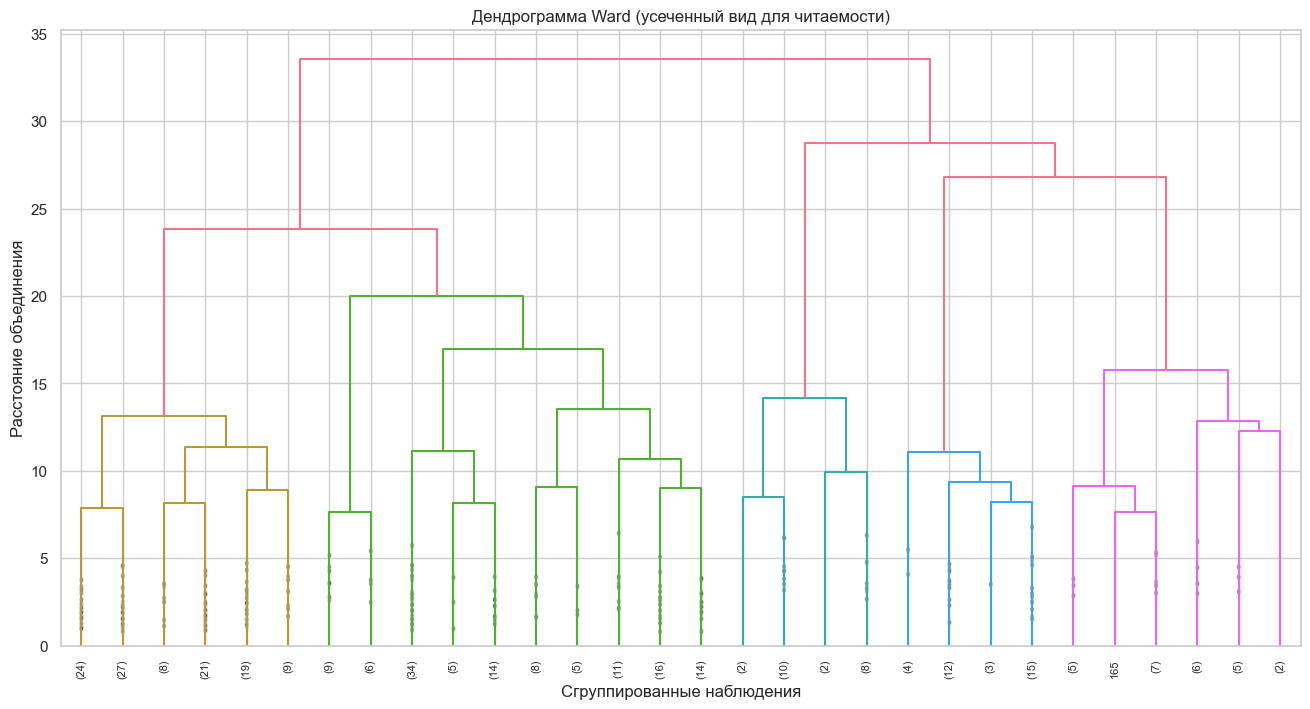

In [10]:
samples = X_scaled.values
mergings = linkage(samples, method="ward")

plt.figure(figsize=(16, 8))
dendrogram(
    mergings,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
)
plt.title("Дендрограмма Ward (усеченный вид для читаемости)")
plt.xlabel("Сгруппированные наблюдения")
plt.ylabel("Расстояние объединения")
plt.show()


In [11]:
agg_rows = []
for n in [2, 3, 5]:
    agg_model = AgglomerativeClustering(n_clusters=n, linkage="ward")
    agg_labels = agg_model.fit_predict(X_scaled)
    agg_rows.append(
        {
            "n_clusters": n,
            "silhouette": metrics.silhouette_score(X_scaled, agg_labels),
            "ari": adjusted_rand_score(y, agg_labels),
        }
    )

agg_results_df = pd.DataFrame(agg_rows)
display(agg_results_df.round(4))


,n_clusters,silhouette,ari
0,2,0.2356,0.1938
1,3,0.2342,0.1701
2,5,0.1172,0.1481


Иерархическая кластеризация показывает ту же общую картину: данные действительно распадаются на несколько
крупных ветвей, но границы между промежуточными группами остаются не очень резкими


# DBSCAN


Для DBSCAN параметры eps и min_samples сильно влияют на результат. Поэтому сначала проверим
небольшую сетку параметров, а затем выберем конфигурацию, которая дает не меньше трех кластеров
и разумное согласование с Status


In [12]:
dbscan_rows = []
eps_grid = [1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8]
min_samples_grid = [3, 4, 5, 6, 8, 10, 12]

for eps in eps_grid:
    for min_samples in min_samples_grid:
        db_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise = int((db_labels == -1).sum())
        mask = db_labels != -1

        silhouette = np.nan
        if n_clusters >= 2 and mask.sum() > 1 and len(set(db_labels[mask])) > 1:
            silhouette = metrics.silhouette_score(X_scaled.loc[mask], db_labels[mask])

        ari = adjusted_rand_score(y, db_labels)

        dbscan_rows.append(
            {
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "n_noise": n_noise,
                "silhouette": silhouette,
                "ari": ari,
            }
        )

dbscan_grid_df = pd.DataFrame(dbscan_rows)
dbscan_valid_df = dbscan_grid_df[dbscan_grid_df["n_clusters"] >= 2].copy()
dbscan_candidates_df = dbscan_valid_df[dbscan_valid_df["n_clusters"] >= 3].copy()

print("Лучшие варианты DBSCAN по ARI (не меньше 3 кластеров):")
display(
    dbscan_candidates_df.sort_values(["ari", "silhouette"], ascending=[False, False])
    .head(10)
    .round(4)
)

print("Лучшие варианты DBSCAN по silhouette (не меньше 2 кластеров):")
display(
    dbscan_valid_df.sort_values(["silhouette", "ari"], ascending=[False, False])
    .head(10)
    .round(4)
)


Лучшие варианты DBSCAN по ARI (не меньше 3 кластеров):


,eps,min_samples,n_clusters,n_noise,silhouette,ari
42,2.6,3,3,103,0.2376,0.2627
37,2.4,5,3,144,0.1483,0.2513
35,2.4,3,6,117,0.1114,0.2507
36,2.4,4,6,127,0.0992,0.2485
49,2.8,3,5,85,0.2008,0.2445
28,2.2,3,6,146,0.1195,0.1923
29,2.2,4,5,155,0.1024,0.1746
30,2.2,5,3,164,0.1183,0.1632
33,2.2,10,3,186,0.1603,0.1227
21,2.0,3,10,165,0.2211,0.0759


Лучшие варианты DBSCAN по silhouette (не меньше 2 кластеров):


,eps,min_samples,n_clusters,n_noise,silhouette,ari
3,1.4,6,2,296,0.5384,-0.0034
2,1.4,5,2,286,0.4877,-0.0107
12,1.6,10,2,282,0.4661,-0.0242
20,1.8,12,2,256,0.3986,-0.0171
11,1.6,8,3,264,0.3091,-0.0239
9,1.6,5,5,236,0.2898,-0.0142
10,1.6,6,3,255,0.2753,-0.0216
0,1.4,3,9,244,0.2609,-0.0258
52,2.8,6,2,107,0.2581,0.2810
8,1.6,4,6,229,0.2560,-0.0145


In [13]:
best_dbscan_row = (
    dbscan_candidates_df.sort_values(["ari", "silhouette"], ascending=[False, False]).iloc[0]
)

dbscan_eps = float(best_dbscan_row["eps"])
dbscan_min_samples = int(best_dbscan_row["min_samples"])

dbscan_model = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
dbscan_labels = dbscan_model.fit_predict(X_scaled)

core_samples_mask = np.zeros_like(dbscan_model.labels_, dtype=bool)
core_samples_mask[dbscan_model.core_sample_indices_] = True

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = int((dbscan_labels == -1).sum())

print(f"Выбранные параметры DBSCAN: eps = {dbscan_eps}, min_samples = {dbscan_min_samples}")
print(f"Число кластеров: {n_clusters_dbscan}")
print(f"Число шумовых точек: {n_noise_dbscan}")


Выбранные параметры DBSCAN: eps = 2.6, min_samples = 3
Число кластеров: 3
Число шумовых точек: 103


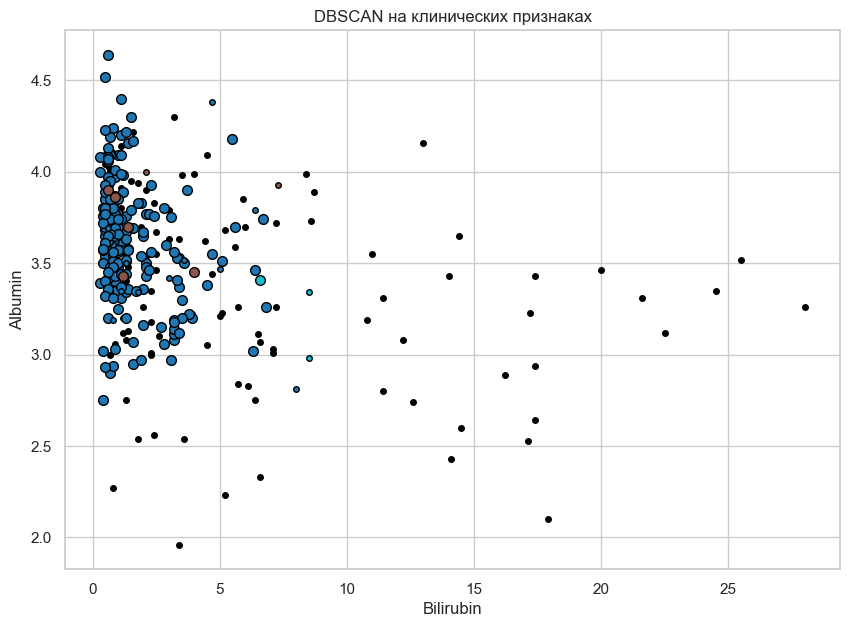

In [14]:
plt.figure(figsize=(10, 7))

unique_labels = sorted(set(dbscan_labels))
positive_labels = [label for label in unique_labels if label != -1]
palette = plt.cm.tab10(np.linspace(0, 1, max(len(positive_labels), 1)))
color_map = {label: palette[idx] for idx, label in enumerate(positive_labels)}
color_map[-1] = "k"

for label in unique_labels:
    class_member_mask = dbscan_labels == label
    color = color_map[label]

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[plot_cols[0]],
        xy[plot_cols[1]],
        "o",
        markerfacecolor=color,
        markeredgecolor="k",
        markersize=7,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[plot_cols[0]],
        xy[plot_cols[1]],
        "o",
        markerfacecolor=color,
        markeredgecolor="k",
        markersize=4,
    )

plt.title("DBSCAN на клинических признаках")
plt.xlabel(plot_cols[0])
plt.ylabel(plot_cols[1])
plt.show()


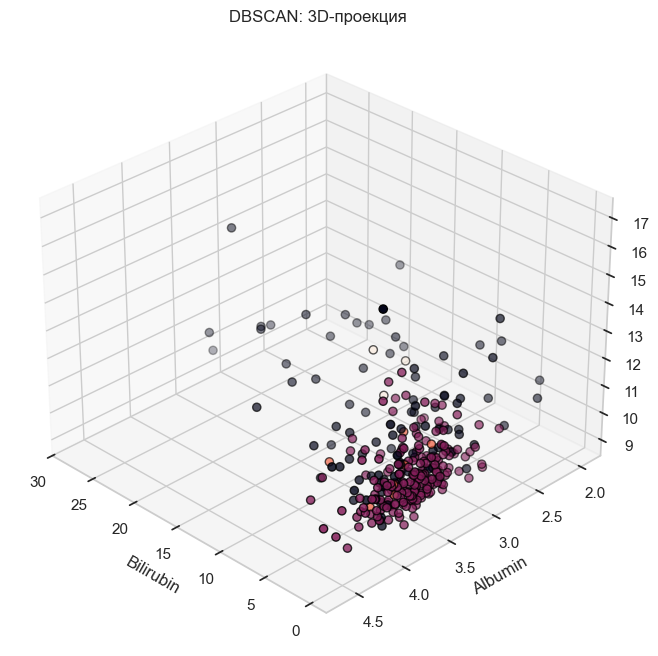

In [15]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=30, azim=135)
ax.scatter(
    X[plot_cols[0]],
    X[plot_cols[1]],
    X[plot_cols[2]],
    c=dbscan_labels.astype(float),
    edgecolor="k",
    s=35,
)
ax.set_xlabel(plot_cols[0])
ax.set_ylabel(plot_cols[1])
ax.set_zlabel(plot_cols[2])
ax.set_title("DBSCAN: 3D-проекция")
plt.show()


In [16]:
dbscan_mask = dbscan_labels != -1
dbscan_silhouette = metrics.silhouette_score(
    X_scaled.loc[dbscan_mask],
    dbscan_labels[dbscan_mask],
)
dbscan_ari = adjusted_rand_score(y, dbscan_labels)

dbscan_status_df = pd.crosstab(
    pd.Series(dbscan_labels, name="Кластер"),
    y,
    normalize="index",
).round(3)

print(f"Silhouette для выбранного DBSCAN: {dbscan_silhouette:.4f}")
print(f"ARI для выбранного DBSCAN: {dbscan_ari:.4f}")
print("Доли классов Status внутри кластеров DBSCAN:")
display(dbscan_status_df)


Silhouette для выбранного DBSCAN: 0.2376
ARI для выбранного DBSCAN: 0.2627
Доли классов Status внутри кластеров DBSCAN:


Status,0,1,2
Кластер,,,
-1,0.204,0.049,0.748
0,0.729,0.065,0.206
1,0.143,0.143,0.714
2,0.333,0.000,0.667


DBSCAN оказался чувствителен к выбору параметров, но после подбора смог выделить три кластера
и отдельный слой шумовых наблюдений. Это полезно с клинической точки зрения: плотностный метод
часто выталкивает в шум именно самые нетипичные и тяжелые случа


# Вывод


In [17]:
best_k_sil = int(best_by_silhouette["n_clusters"])
best_k_ari = int(best_by_ari["n_clusters"])
best_k_sil_value = float(best_by_silhouette["silhouette"])
best_k_ari_value = float(best_by_ari["ari"])

best_agg_row = agg_results_df.sort_values(["ari", "silhouette"], ascending=[False, False]).iloc[0]

print(
    f"1. По метрике silhouette лучший KMeans получился при k = {best_k_sil} "
    f"(silhouette = {best_k_sil_value:.4f}). Это говорит о наличии сильного грубого разделения "
    f"между более тяжелыми и более легкими наблюдениями."
)
print(
    f"2. По ARI лучший KMeans получился при k = {best_k_ari} "
    f"(ARI = {best_k_ari_value:.4f}). Значит, более детальное разбиение лучше согласуется "
    f"с внешней меткой Status, хотя кластеры становятся менее компактными."
)
print(
    "3. Профили кластеров показывают, что основные различия связаны с Bilirubin, Albumin, "
    "Copper, Platelets и Prothrombin. То есть кластеры действительно отражают тяжесть состояния."
)
print(
    f"4. Иерархическая кластеризация тоже подтверждает наличие нескольких крупных групп. "
    f"Лучший рассмотренный вариант для AgglomerativeClustering дал ARI = {best_agg_row['ari']:.4f}."
)
print(
    f"5. После подбора параметров DBSCAN дал {n_clusters_dbscan} кластера(ов) и {n_noise_dbscan} "
    f"шумовых точек, при этом ARI = {dbscan_ari:.4f}. Это означает, что плотностный метод может быть "
    "полезен для поиска нетипичных пациентов, но чувствителен к настройке."
)
print(
    "6. Для этого датасета разумно использовать Status как внешнюю метку для интерпретации кластеров. "
    "Сами кластеры не совпадают с ней идеально, но хорошо разделяют пациентов по степени выраженности "
    "клинических показателей."
)


1. По метрике silhouette лучший KMeans получился при k = 2 (silhouette = 0.3399). Это говорит о наличии сильного грубого разделения между более тяжелыми и более легкими наблюдениями.
2. По ARI лучший KMeans получился при k = 5 (ARI = 0.2452). Значит, более детальное разбиение лучше согласуется с внешней меткой Status, хотя кластеры становятся менее компактными.
3. Профили кластеров показывают, что основные различия связаны с Bilirubin, Albumin, Copper, Platelets и Prothrombin. То есть кластеры действительно отражают тяжесть состояния.
4. Иерархическая кластеризация тоже подтверждает наличие нескольких крупных групп. Лучший рассмотренный вариант для AgglomerativeClustering дал ARI = 0.1938.
5. После подбора параметров DBSCAN дал 3 кластера(ов) и 103 шумовых точек, при этом ARI = 0.2627. Это означает, что плотностный метод может быть полезен для поиска нетипичных пациентов, но чувствителен к настройке.
6. Для этого датасета разумно использовать Status как внешнюю метку для интерпретации 